In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/processed/visa_cleaned_with_processing_time.csv")


In [2]:
df.shape
df.columns


Index(['age', 'nationality', 'current_residence', 'marital_status',
       'dependents', 'education_level', 'occupation', 'work_experience_years',
       'sponsorship_status', 'financial_status', 'language_proficiency',
       'purpose_of_travel', 'intended_duration', 'travel_history',
       'target_country', 'visa_category (Label)', 'previous_visa_rejections',
       'criminal_record_check', 'medical_exam_status',
       'document_completeness_score', 'visa_fee_payment_status',
       'processing_time_days'],
      dtype='object')

In [3]:
df.dtypes


age                            float64
nationality                     object
current_residence               object
marital_status                  object
dependents                     float64
education_level                 object
occupation                      object
work_experience_years          float64
sponsorship_status              object
financial_status                object
language_proficiency            object
purpose_of_travel               object
intended_duration                int64
travel_history                  object
target_country                  object
visa_category (Label)           object
previous_visa_rejections         int64
criminal_record_check           object
medical_exam_status             object
document_completeness_score      int64
visa_fee_payment_status         object
processing_time_days             int64
dtype: object

In [4]:
df.isnull().sum()


age                            0
nationality                    0
current_residence              0
marital_status                 0
dependents                     0
education_level                0
occupation                     0
work_experience_years          0
sponsorship_status             0
financial_status               0
language_proficiency           0
purpose_of_travel              0
intended_duration              0
travel_history                 0
target_country                 0
visa_category (Label)          0
previous_visa_rejections       0
criminal_record_check          0
medical_exam_status            0
document_completeness_score    0
visa_fee_payment_status        0
processing_time_days           0
dtype: int64

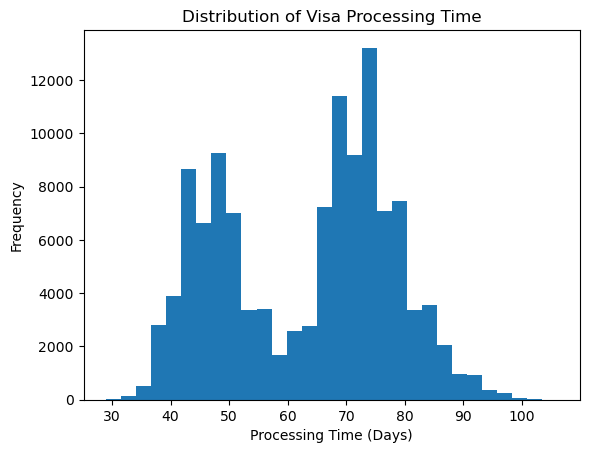

In [5]:
plt.hist(df['processing_time_days'], bins=30)
plt.xlabel("Processing Time (Days)")
plt.ylabel("Frequency")
plt.title("Distribution of Visa Processing Time")
plt.show()


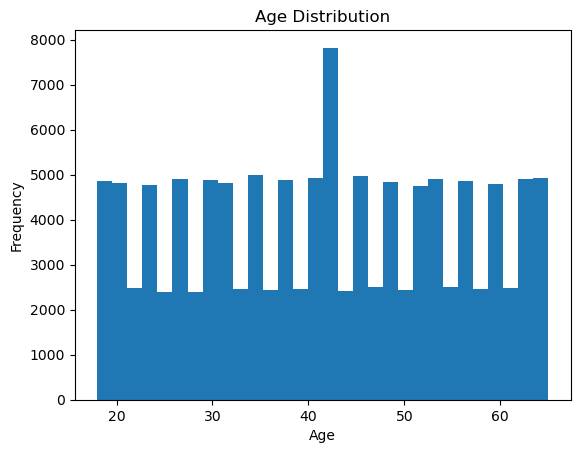

In [6]:
plt.hist(df['age'], bins=30)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()


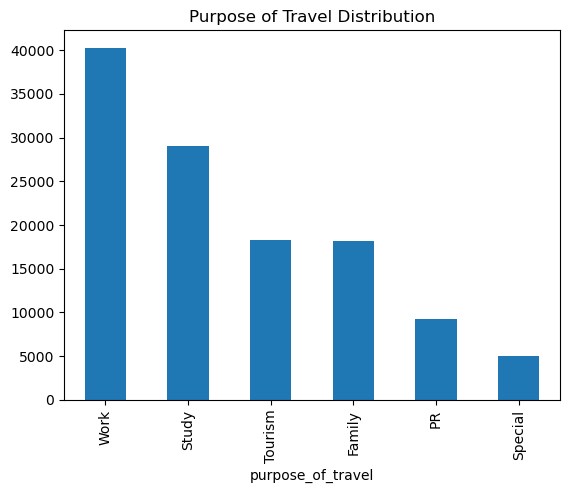

In [7]:
df['purpose_of_travel'].value_counts().plot(kind='bar')
plt.title("Purpose of Travel Distribution")
plt.show()


In [8]:
df['visa_category (Label)'] = df['visa_category (Label)'].str.strip().str.lower()

df['visa_category (Label)'] = df['visa_category (Label)'].replace({
    'visitorrr': 'visitor',
    'visitor ': 'visitor'
})


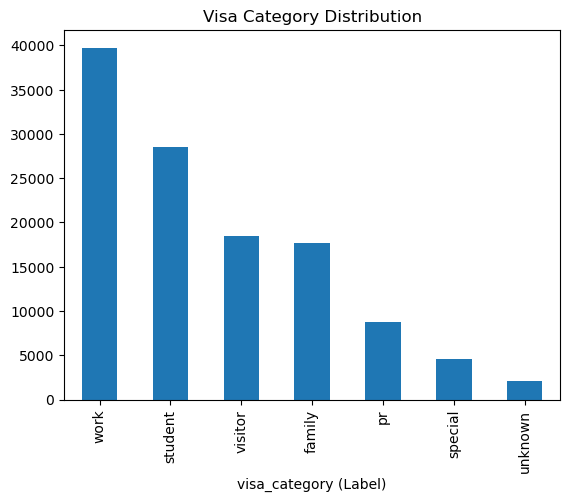

In [9]:
df['visa_category (Label)'].value_counts().plot(kind='bar')
plt.title("Visa Category Distribution")
plt.show()


In [10]:
df.shape
df.columns
df.dtypes
df.isnull().sum()


age                            0
nationality                    0
current_residence              0
marital_status                 0
dependents                     0
education_level                0
occupation                     0
work_experience_years          0
sponsorship_status             0
financial_status               0
language_proficiency           0
purpose_of_travel              0
intended_duration              0
travel_history                 0
target_country                 0
visa_category (Label)          0
previous_visa_rejections       0
criminal_record_check          0
medical_exam_status            0
document_completeness_score    0
visa_fee_payment_status        0
processing_time_days           0
dtype: int64

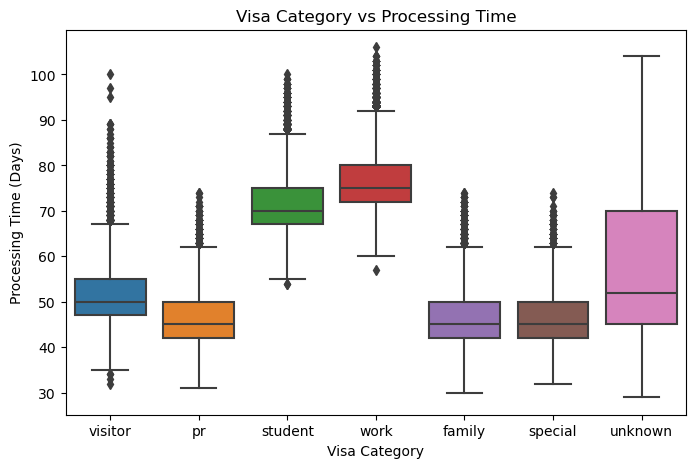

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df['visa_category (Label)'],
    y=df['processing_time_days']
)
plt.xlabel("Visa Category")
plt.ylabel("Processing Time (Days)")
plt.title("Visa Category vs Processing Time")
plt.show()


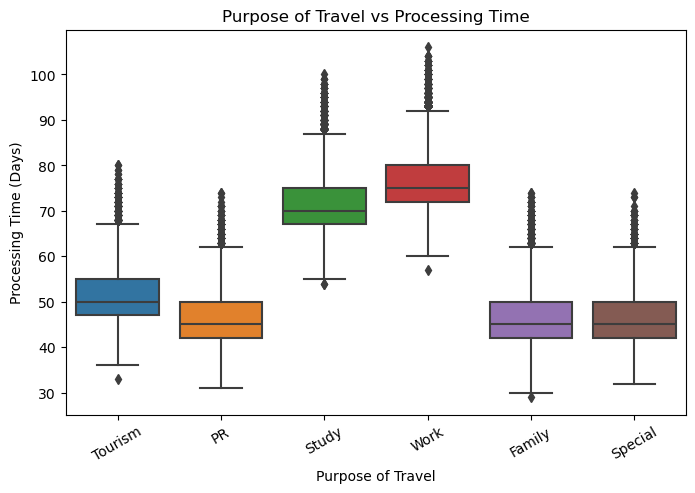

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df['purpose_of_travel'],
    y=df['processing_time_days']
)
plt.xticks(rotation=30)
plt.xlabel("Purpose of Travel")
plt.ylabel("Processing Time (Days)")
plt.title("Purpose of Travel vs Processing Time")
plt.show()


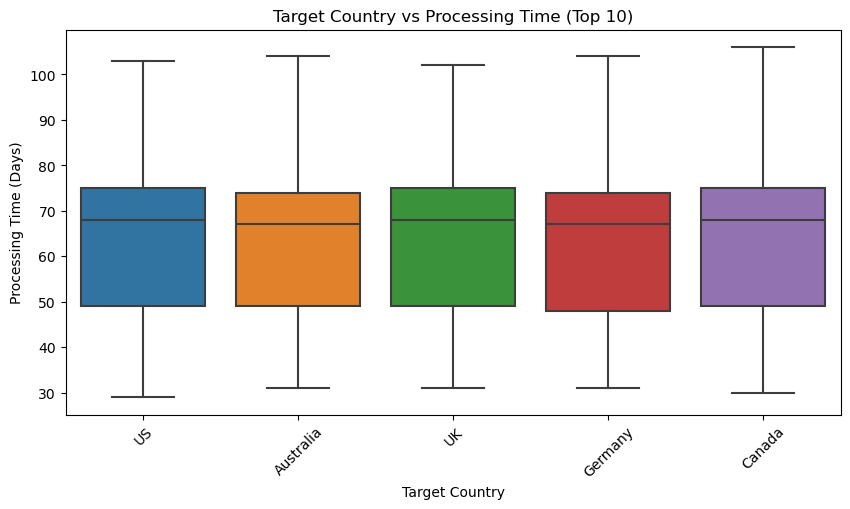

In [13]:
top_countries = df['target_country'].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.boxplot(
    x='target_country',
    y='processing_time_days',
    data=df[df['target_country'].isin(top_countries)]
)
plt.xticks(rotation=45)
plt.xlabel("Target Country")
plt.ylabel("Processing Time (Days)")
plt.title("Target Country vs Processing Time (Top 10)")
plt.show()


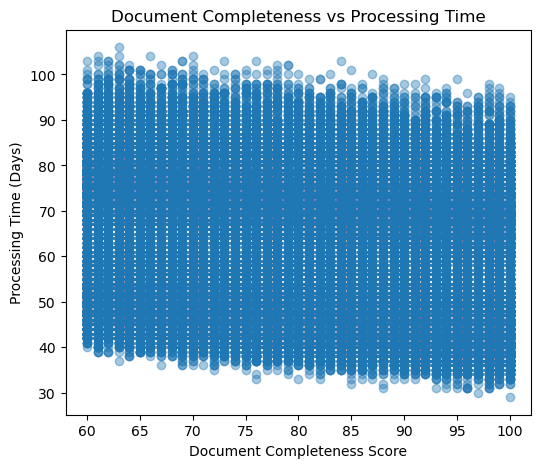

In [14]:
plt.figure(figsize=(6,5))
plt.scatter(
    df['document_completeness_score'],
    df['processing_time_days'],
    alpha=0.4
)
plt.xlabel("Document Completeness Score")
plt.ylabel("Processing Time (Days)")
plt.title("Document Completeness vs Processing Time")
plt.show()


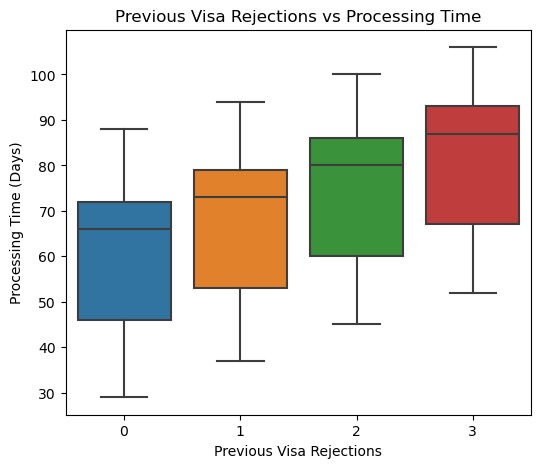

In [15]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x=df['previous_visa_rejections'],
    y=df['processing_time_days']
)
plt.xlabel("Previous Visa Rejections")
plt.ylabel("Processing Time (Days)")
plt.title("Previous Visa Rejections vs Processing Time")
plt.show()


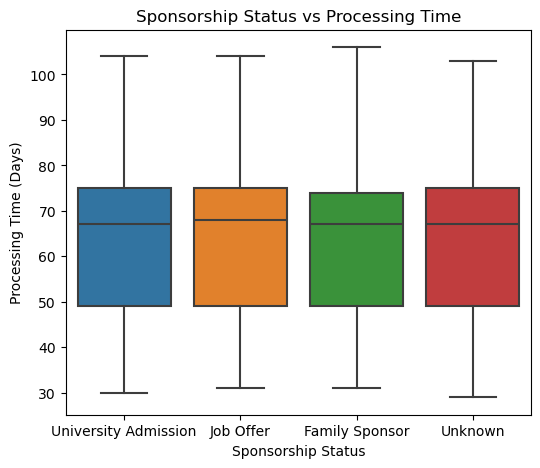

In [16]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x=df['sponsorship_status'],
    y=df['processing_time_days']
)
plt.xlabel("Sponsorship Status")
plt.ylabel("Processing Time (Days)")
plt.title("Sponsorship Status vs Processing Time")
plt.show()


In [17]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
numeric_df.columns



Index(['age', 'dependents', 'work_experience_years', 'intended_duration',
       'previous_visa_rejections', 'document_completeness_score',
       'processing_time_days'],
      dtype='object')

In [18]:
corr_matrix = numeric_df.corr()
corr_matrix


,age,dependents,work_experience_years,intended_duration,previous_visa_rejections,document_completeness_score,processing_time_days
age,1.000000,0.006954,-0.001664,0.004762,0.000584,-0.001790,0.002731
dependents,0.006954,1.000000,0.003534,0.007172,-0.001643,-0.002986,0.007157
work_experience_years,-0.001664,0.003534,1.000000,-0.002191,0.001966,0.005902,-0.002115
intended_duration,0.004762,0.007172,-0.002191,1.000000,-0.003446,0.001232,0.847181
previous_visa_rejections,0.000584,-0.001643,0.001966,-0.003446,1.000000,-0.001997,0.343518
document_completeness_score,-0.001790,-0.002986,0.005902,0.001232,-0.001997,1.000000,-0.162510
processing_time_days,0.002731,0.007157,-0.002115,0.847181,0.343518,-0.162510,1.000000


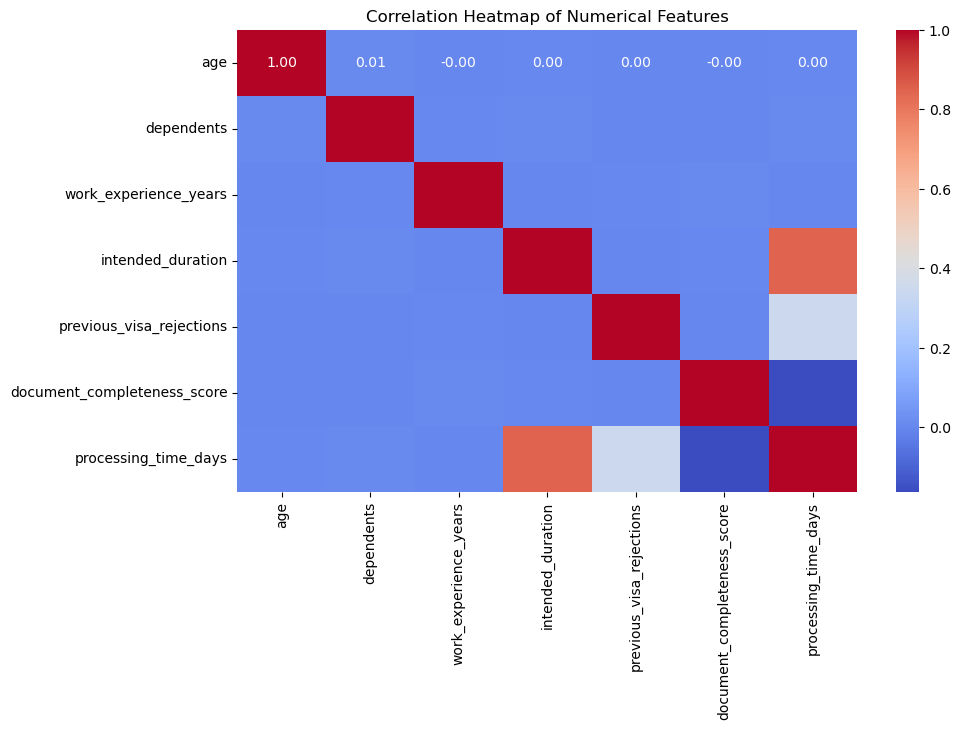

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


In [20]:
corr_matrix['processing_time_days'].sort_values(ascending=False)


processing_time_days           1.000000
intended_duration              0.847181
previous_visa_rejections       0.343518
dependents                     0.007157
age                            0.002731
work_experience_years         -0.002115
document_completeness_score   -0.162510
Name: processing_time_days, dtype: float64

In [21]:
df['purpose_of_travel'] = df['purpose_of_travel'].str.strip().str.lower()


In [22]:
season_map = {
    'medical': 0.9,
    'family': 0.9,
    'business': 1.0,
    'tourism': 1.2,
    'study': 1.4,
    'work': 1.4
}

df['seasonal_index'] = df['purpose_of_travel'].map(season_map).fillna(1.0)


In [23]:
df['seasonal_index'].value_counts()


seasonal_index
1.4    69285
1.2    18264
0.9    18110
1.0    14341
Name: count, dtype: int64

In [24]:
country_avg = df.groupby('target_country')['processing_time_days'].mean()

df['country_avg_processing_time'] = df['target_country'].map(country_avg)


In [25]:
df['risk_score'] = (
    df['previous_visa_rejections'] * 2 +
    (100 - df['document_completeness_score']) / 10
)


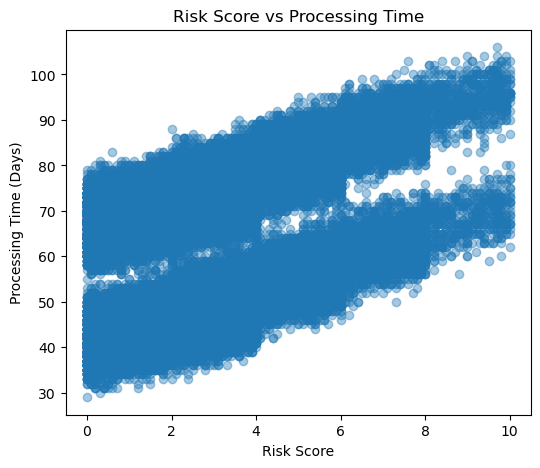

In [26]:
plt.figure(figsize=(6,5))
plt.scatter(df['risk_score'], df['processing_time_days'], alpha=0.4)
plt.xlabel("Risk Score")
plt.ylabel("Processing Time (Days)")
plt.title("Risk Score vs Processing Time")
plt.show()


In [27]:
df['seasonal_index'] = np.where(
    df['purpose_of_travel'].isin(['tourism', 'business']),
    'Peak',
    'Off-Peak'
)


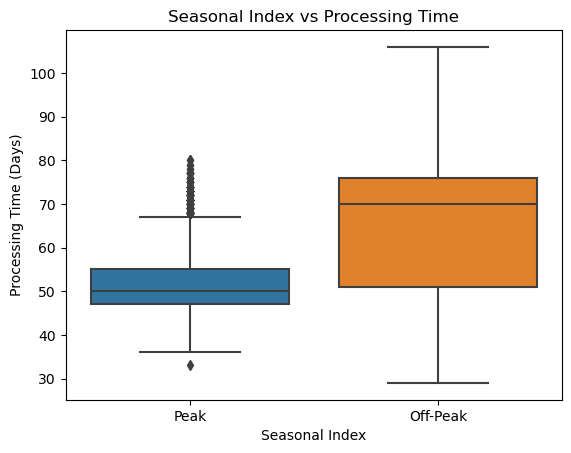

In [28]:
sns.boxplot(
    x=df['seasonal_index'],
    y=df['processing_time_days']
)
plt.xlabel("Seasonal Index")
plt.ylabel("Processing Time (Days)")
plt.title("Seasonal Index vs Processing Time")
plt.show()


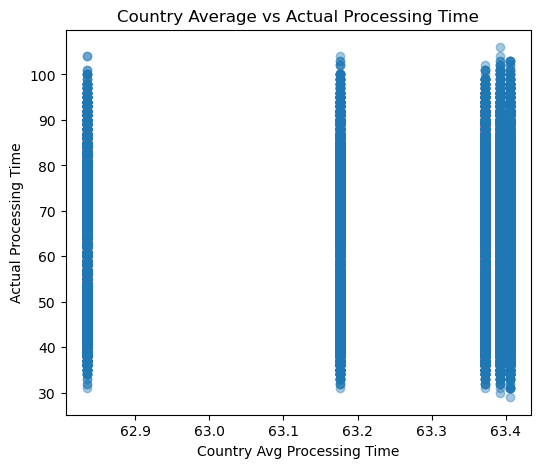

In [29]:
plt.figure(figsize=(6,5))
plt.scatter(
    df['country_avg_processing_time'],
    df['processing_time_days'],
    alpha=0.4
)
plt.xlabel("Country Avg Processing Time")
plt.ylabel("Actual Processing Time")
plt.title("Country Average vs Actual Processing Time")
plt.show()


In [30]:
df.to_csv("../data/processed/visa_feature_engineered.csv", index=False)
